In [1]:
import pandas as pd
import numpy as np

# 1. Load the dataset you saved earlier
df = pd.read_csv('heart_disease.csv')

# 2. Description of the dataset (Rubric Item #2)
print("Dataset Shape:", df.shape) # Shows rows and columns 
print(df.info()) # Shows attribute names and data types 

# 3. Data Preprocessing: Check for missing values (Rubric Item #3)
# The UCI Heart Disease dataset often uses '?' for missing values
df = df.replace('?', np.nan)
print("Missing values per column:\n", df.isnull().sum())

# 4. Cleansing: Drop rows with missing values or fill them
df = df.dropna() 

# 5. Preview the cleaned data
df.head()

Dataset Shape: (303, 14)
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB
None
Missing values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [2]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Define inputs (x) and target (y)
# Drop 'num' from x cuz thats the prediction
x = df.drop('num', axis=1)
y = df['num']

# 2. split the data into Training and testing (80% , 20%)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 3. Create Random Forest Model 
# n_estimators=100 means we are using 100 trees in the forest
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 4. Train the model 
model.fit(X_train, y_train)

# 5. Make predictions and check accuracy
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Random Forest Accuracy: {accuracy * 100:.2f}%")

Random Forest Accuracy: 60.00%


In [5]:
%pip install seaborn matplotlib

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 1.9 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/8.3 MB 1.1 MB/s eta 0:00:07
   ------ --------------------------------- 1.3/8.3 MB 1.6 MB/s eta 0:00:05
   ------ --------------------------------- 1.3/8.3 MB 1.6 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.3 MB 1.3 MB/s eta 0:00:05
   -------- ------------------------------- 1.8/8.3 MB 1.3 MB/s eta 0:00:05
   ---------- ----------------------------- 2.1/8.3 MB 1.3 MB/s eta 0:00:05
   ----------- ---------------------------- 2.4/8.3 MB 1.3 MB/s eta 0:00:05
   ------------ --------------------------- 2.6/8.3 MB 1.3 MB/s eta 0:00:05
   ------------- -------------------------- 2.9/8.3 MB 1.2 MB/s eta 0:00:05
   --------------- ------------------------ 3.1/8.3 MB 1.2 MB/s eta 0:00:05
   --------------- -------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.97      0.88        36
           1       0.00      0.00      0.00         9
           2       0.14      0.20      0.17         5
           3       0.00      0.00      0.00         7
           4       0.00      0.00      0.00         3

    accuracy                           0.60        60
   macro avg       0.19      0.23      0.21        60
weighted avg       0.49      0.60      0.54        60



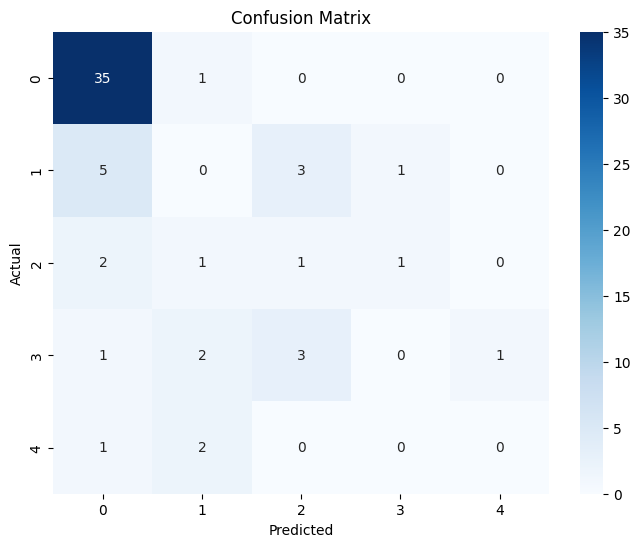

In [3]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Print a detaild report (Precision, Recall, F1-score)
print ("Classification Report:\n", classification_report(y_test,predictions))

# 2.Create a confution Matrix to visualize
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [4]:
# 1. Create a copy of data
df_binary = df.copy()

# 2. Change 'num' so that anything > 0 becoms 1 (Sick)
# 0 remains 0 (Healthy)
df_binary['num'] = df_binary['num'].apply(lambda x: 1 if x > 0 else 0)

# 3. Re-split and Re-Train
X_b = df_binary.drop('num', axis=1)
y_b = df_binary['num']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, test_size=0.2, random_state=42)

# 4. Runing Random Forest again
model_b = RandomForestClassifier(n_estimators=100, random_state=42)
model_b.fit(X_train_b, y_train_b)

# 5. Check new accuracy
preds_b = model_b.predict(X_test_b)
from sklearn.metrics import accuracy_score
print(f"Binary Classification Accuracy: {accuracy_score(y_test_b, preds_b) * 100:.2f}%")

Binary Classification Accuracy: 88.33%


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Get the importance scores from your binary model
importances = model_b.feature_importances_
feature_names = X_b.columns

# 2. Create a DataFrame for easy plotting
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Plot the reasults
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Most Important Features for Heart Disease Prediction(Random Forest)')
plt.show()